# Project: Global Air Quality Analysis (PM2.5)

### By: Charity Okpanachi

## Introduction

Air pollution remains one of the most pressing environmental and public health challenges globally, with fine particulate matter (PM2.5) being a major contributor to poor air quality. Due to its small size, PM2.5 can penetrate deep into the respiratory system, posing serious health risks and reducing overall quality of life.

Across different cities, pollution levels vary significantly due to factors such as industrial activities, urbanization, and weather conditions. Understanding these variations and how air pollution changes over time is essential for effective environmental monitoring and decision-making.

In rapidly growing cities like Lagos, air quality concerns are particularly important due to increasing population density and economic activity. Analyzing historical pollution data can provide valuable insights into patterns and trends, while forecasting future levels can support proactive planning and intervention.

### Objective

This project examines global PM2.5 pollution patterns and applies time-series forecasting techniques to predict future air pollution levels in Lagos using historical data.


In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load dataset
air_data = pd.read_csv("air_quality_global.csv")

# View first few rows
air_data.head(3)

,city,country,latitude,longitude,year,month,pm25_ugm3,no2_ugm3,data_quality,measurement_method,data_source
0,New York,USA,40.7128,-74.006,1999,1,18.11,35.98,Moderate,Reference/Equivalent Method,EPA_AQS
1,New York,USA,40.7128,-74.006,1999,2,27.79,17.71,Good,Reference/Equivalent Method,EPA_AQS
2,New York,USA,40.7128,-74.006,1999,3,12.05,40.99,Moderate,Reference/Equivalent Method,EPA_AQS


In [3]:
air_data.shape

(6480, 11)

In [4]:
air_data.duplicated().sum()

0

In [5]:
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   city                6480 non-null   object 
 1   country             6480 non-null   object 
 2   latitude            6480 non-null   float64
 3   longitude           6480 non-null   float64
 4   year                6480 non-null   int64  
 5   month               6480 non-null   int64  
 6   pm25_ugm3           6480 non-null   float64
 7   no2_ugm3            6480 non-null   float64
 8   data_quality        6480 non-null   object 
 9   measurement_method  6480 non-null   object 
 10  data_source         6480 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 557.0+ KB


#### Obervation:
* The dataset contains 6,480 records of air quality measurements for major global cities.
* Each observation represents a city’s pollution level recorded at a specific month and year, enabling both cross-city comparisons and time-series analysis of air pollution trends.
* The dataset is clean with no duplicates or missing values

### Global PM2.5 Comparison

In [6]:
# Calculate the average PM2.5 concentrate for each city
city_pm25 = air_data.groupby("city")["pm25_ugm3"].mean().sort_values(ascending=False)

city_pm25

city
Delhi           132.012099
Mumbai           99.264969
Beijing          75.325123
Lagos            66.638086
Mexico City      53.446698
São Paulo        40.879691
Los Angeles      31.246728
Tokyo            29.550494
London           29.103148
Houston          27.790216
Paris            27.201821
San Antonio      25.129599
Berlin           24.725062
Chicago          24.546667
Dallas           23.785432
San Jose         23.401698
Philadelphia     23.380123
New York         21.471327
Phoenix          20.750926
San Diego        19.714290
Name: pm25_ugm3, dtype: float64

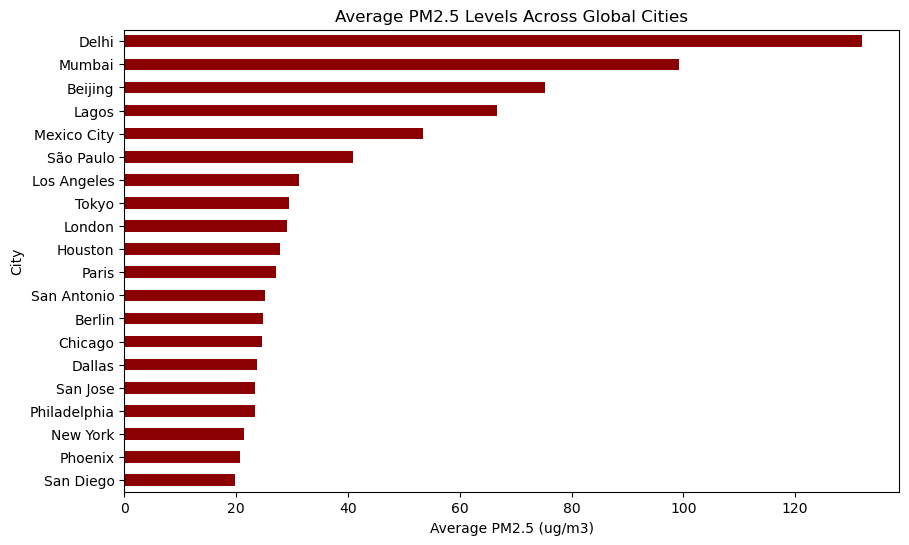

In [7]:
# Visualize the average PM2.5 concentration for each city
city_pm25.sort_values().plot(kind="barh", figsize=(10, 6), color="darkred")

plt.title("Average PM2.5 Levels Across Global Cities")
plt.xlabel("Average PM2.5 (ug/m3)")
plt.ylabel("City")

# Save visual
plt.savefig("city_comparison.png") 

plt.show()

#### Observation:
* Air pollution levels are very different from one city to another. 
* Delhi and Mumbai have the highest pollution levels among the cities studied. They are followed by Beijing and Lagos. Meaning that the air in these cities contains much more Particulate Matter 2.5.

* Lagos has noticeably higher pollution levels compared to cities such as London, New York, and San Diego,.

* This implies that some fast-growing cities are facing more serious air quality problems, which can affect the health of people living there.

## Global Trend Analysis

In [7]:
yearly_pm25 = air_data.groupby("year")["pm25_ugm3"].mean()

yearly_pm25

year
1999    41.087417
2000    42.065833
2001    40.752500
2002    37.325250
2003    40.317042
2004    39.975708
2005    39.723417
2006    40.436542
2007    38.753708
2008    38.613500
2009    39.288667
2010    42.901875
2011    42.727708
2012    42.964750
2013    40.768917
2014    42.796125
2015    42.552083
2016    41.145208
2017    42.992833
2018    41.914125
2019    40.752583
2020    42.487958
2021    42.128375
2022    39.610125
2023    42.256542
2024    40.413958
2025    39.388917
Name: pm25_ugm3, dtype: float64

In [8]:
yearly_pm25.sort_values(ascending=False)

year
2017    42.992833
2012    42.964750
2010    42.901875
2014    42.796125
2011    42.727708
2015    42.552083
2020    42.487958
2023    42.256542
2021    42.128375
2000    42.065833
2018    41.914125
2016    41.145208
1999    41.087417
2013    40.768917
2019    40.752583
2001    40.752500
2006    40.436542
2024    40.413958
2003    40.317042
2004    39.975708
2005    39.723417
2022    39.610125
2025    39.388917
2009    39.288667
2007    38.753708
2008    38.613500
2002    37.325250
Name: pm25_ugm3, dtype: float64

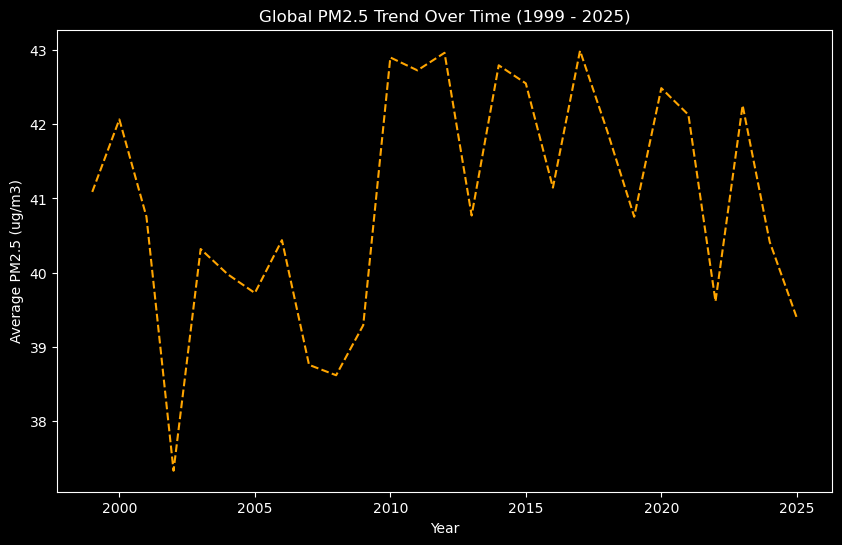

In [10]:
# Visualize the global trend
plt.style.use("dark_background")
yearly_pm25.plot(figsize=(10, 6), color="orange", linestyle="--")

plt.title("Global PM2.5 Trend Over Time (1999 - 2025)")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (ug/m3)")

# Save visual
plt.savefig("yearly_global trend.png")

plt.show()

#### Observation:
* Looking at air pollution levels around the world from 1999 to 2025. The results show that pollution levels have not changed very much over time. Instead, they have gone up and down slightly from year to year.

* Pollution levels were highest between about 2010 and 2017, while there were small decreases in the early 2000s and in some recent years. However, overall pollution has remained fairly high throughout the entire period.

* This means that many cities around the world have been dealing with air pollution for a long time, and the problem has not improved significantly.

#### These may be influenced by factors such as:

- growth of cities

- industrial activities

- environmental policies introduced in different countries

Overall, the data shows that air pollution continues to be an important global challenge.

## Lagos Analysis

In [9]:
lagos_data = air_data[air_data["city"] == "Lagos"].copy()

lagos_data.head()

,city,country,latitude,longitude,year,month,pm25_ugm3,no2_ugm3,data_quality,measurement_method,data_source
6156,Lagos,Nigeria,6.5244,3.3792,1999,1,52.96,24.56,Good,Reference/Equivalent Method,WHO_Database
6157,Lagos,Nigeria,6.5244,3.3792,1999,2,101.49,33.71,Good,Reference/Equivalent Method,WHO_Database
6158,Lagos,Nigeria,6.5244,3.3792,1999,3,117.04,43.05,Good,Reference/Equivalent Method,WHO_Database
6159,Lagos,Nigeria,6.5244,3.3792,1999,4,58.04,48.74,Good,Reference/Equivalent Method,WHO_Database
6160,Lagos,Nigeria,6.5244,3.3792,1999,5,68.99,69.96,Moderate,Reference/Equivalent Method,WHO_Database


In [10]:
# Calculate yearly average PM2.5 for Lagos
lagos_yearly_pm25 = lagos_data.groupby("year")["pm25_ugm3"].mean()

lagos_yearly_pm25

year
1999    63.550833
2000    71.731667
2001    65.791667
2002    57.452500
2003    71.432500
2004    66.000000
2005    59.780833
2006    62.687500
2007    67.074167
2008    63.025000
2009    71.026667
2010    62.480000
2011    69.827500
2012    68.412500
2013    69.730000
2014    59.397500
2015    71.320833
2016    57.280000
2017    73.706667
2018    67.311667
2019    70.437500
2020    70.161667
2021    61.166667
2022    74.907500
2023    67.906667
2024    72.129167
2025    63.499167
Name: pm25_ugm3, dtype: float64

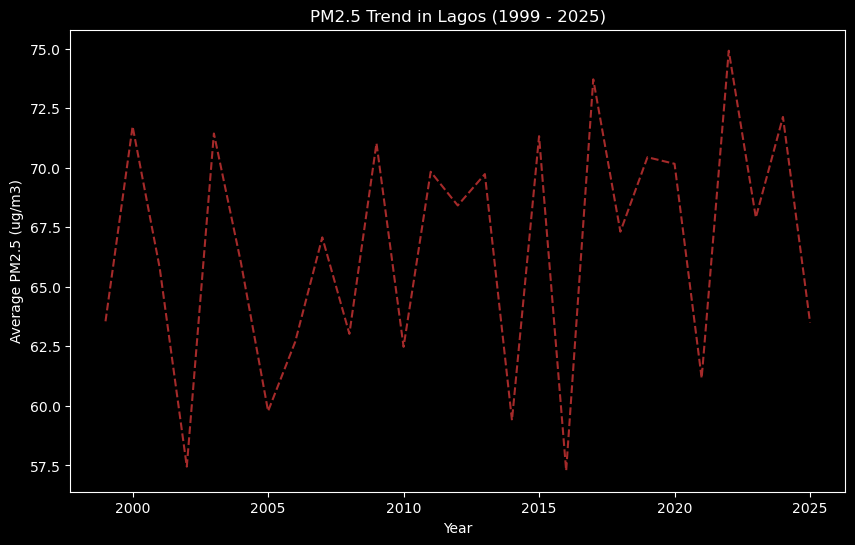

In [17]:
# Plot Lagos PM2.5 trend over time
plt.style.use("dark_background")
lagos_yearly_pm25.plot(figsize=(10, 6), color="brown", linestyle="--")

plt.title("PM2.5 Trend in Lagos (1999 - 2025)")
plt.xlabel("Year")
plt.ylabel("Average PM2.5 (ug/m3)")

# Save visual
plt.savefig("Lagos_yearly_trend.png")

plt.show()

#### Observation:
* The yearly air pollution levels in Lagos from 1999 to 2025 shows that pollution has remained consistently high over the years. On average, the pollution levels stayed between 57 and 75 µg/m³, which is quite high.

* Although the pollution levels go up and down slightly from year to year, there is no clear sign that the problem is improving or getting worse over time. However, the levels are still much higher than the global average, which shows that air pollution remains a serious environmental issue in Lagos.

* This may be linked to factors such as rapid population growth, increased traffic, and expanding urban development in the city.

In [11]:
import calendar

# Calculate monthly average PM2.5 for Lagos
lagos_monthly_pm25 = lagos_data.groupby("month")["pm25_ugm3"].mean()

# Replace month numbers with month names
lagos_monthly_pm25.index = lagos_monthly_pm25.index.map(lambda x: calendar.month_name[x])

lagos_monthly_pm25

month
January      66.487407
February     84.841481
March        76.398889
April        90.808519
May          86.710000
June         77.739630
July         66.909630
August       57.711111
September    49.858519
October      43.035185
November     43.446296
December     55.710370
Name: pm25_ugm3, dtype: float64

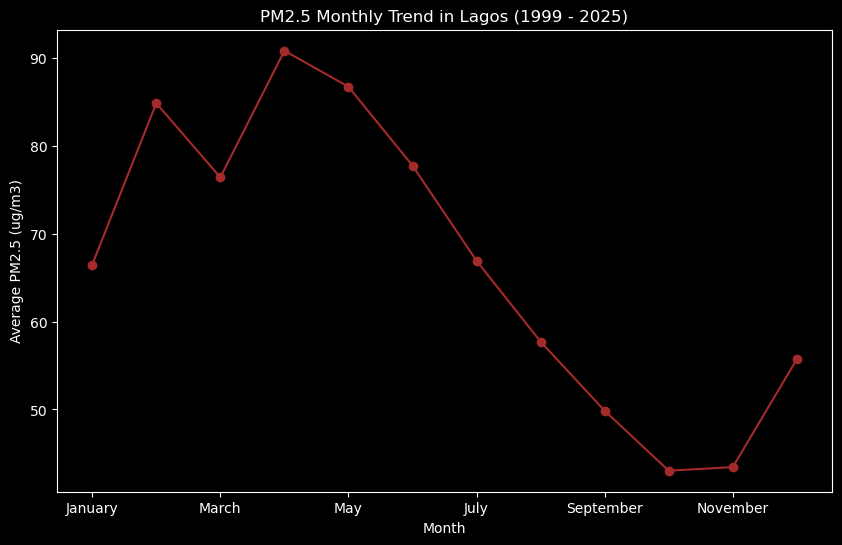

In [23]:
# Plot Lagos PM2.5 trend over time
plt.style.use("dark_background")
lagos_monthly_pm25.plot(figsize=(10, 6), color="brown", marker="o")

plt.title("PM2.5 Monthly Trend in Lagos (1999 - 2025)")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (ug/m3)")

# Save visual
plt.savefig("Lagos_monthlyly_trend.png")

plt.show()

#### Observation: 
This result shows the average amount of Particulate Matter 2.5 in the air during each month for Lagos state. And we can see from the results that air pollution is usually higher at the beginning of the year. For instance

* April has the highest average pollution level (about 90.8).

* February and May also show very high pollution levels.

As the year progresses, pollution levels gradually decrease, especially around the middle of the year.

* The cleanest months appear to be October and November, when the pollution levels are much lower compared to earlier months.

This suggests that air pollution in Lagos follows a seasonal pattern:

* Higher pollution early in the year

* Lower pollution around the middle and later months of the year

This could be influenced by factors such as weather conditions, rainfall, and human activities during different times of the year.

## Prepare Data for Time Series Modelling

In [12]:
# Create a proper datetime column using year and month
lagos_data["date"] = pd.to_datetime(lagos_data[["year", "month"]].assign(day=1))

# Sort the dataset by date
lagos_data = lagos_data.sort_values("date")

# Set the date column as the index for time-series analysis
lagos_data = lagos_data.set_index("date")

# Display the first row
lagos_data.head()

,city,country,latitude,longitude,year,month,pm25_ugm3,no2_ugm3,data_quality,measurement_method,data_source
date,,,,,,,,,,,
1999-01-01,Lagos,Nigeria,6.5244,3.3792,1999,1,52.96,24.56,Good,Reference/Equivalent Method,WHO_Database
1999-02-01,Lagos,Nigeria,6.5244,3.3792,1999,2,101.49,33.71,Good,Reference/Equivalent Method,WHO_Database
1999-03-01,Lagos,Nigeria,6.5244,3.3792,1999,3,117.04,43.05,Good,Reference/Equivalent Method,WHO_Database
1999-04-01,Lagos,Nigeria,6.5244,3.3792,1999,4,58.04,48.74,Good,Reference/Equivalent Method,WHO_Database
1999-05-01,Lagos,Nigeria,6.5244,3.3792,1999,5,68.99,69.96,Moderate,Reference/Equivalent Method,WHO_Database


* The dataset was reorganized so that the year and month were combined into one date. It was also rearranged in the correct order from the earliest date to the most recent date.

* Organizing the data this way is important because it allows us to clearly see how air pollution changes over time. It also makes it easier to study patterns, such as whether pollution increases or decreases during certain periods of the year.

* From the updated dataset, we can see that it now shows monthly air pollution measurements for Lagos, starting from January 1999. Each row now represents pollution levels for a specific month.

* With the data arranged this way, we can easily create charts to show trends over time and also make predictions about future pollution levels.

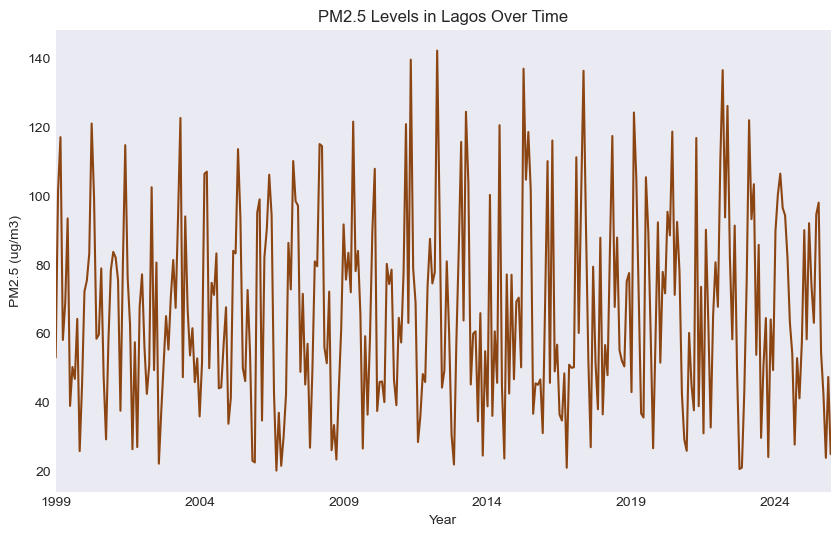

In [27]:
# Plot PM2.5 levels over time
plt.style.use("seaborn-dark")
plt.figure(figsize=(10,6))

lagos_data["pm25_ugm3"].plot(color="saddlebrown")

plt.title("PM2.5 Levels in Lagos Over Time")
plt.xlabel("Year")
plt.ylabel("PM2.5 (ug/m3)")

# Save visual
plt.savefig("PM2.5 Levels in Lagos over time.png")

plt.show()

#### Observation:
* There are 324 monthly records, covering 27 years of air pollution data.

* From the numbers, we can see that pollution levels change a lot from month to month, sometimes increasing sharply and other times dropping significantly. 
* This variation suggests that air pollution in Lagos does not stay constant and may be influenced by seasonal changes, weather conditions, and human activities.

## Stationarity Test (ADF Test)

In [13]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(lagos_data["pm25_ugm3"])

# Print results
print("ADF Statistics:", result[0])
print("p-value:", result[1])

ADF Statistics: -6.575849876723864
p-value: 7.729303627750723e-09


* A statistical test (Augmented Dickey–Fuller Test) was used to check whether the air pollution data for Lagos is stable enough to be used for forecasting.

* The result showed that the data is stable over time. This means that although pollution levels fluctuate from month to month, they generally stay around a similar average level rather than continuously increasing or decreasing.

* Since the data behaves this way, it is suitable for building a forecasting model that can estimate future levels of Particulate Matter 2.5 in Lagos.

## Build the Forecasting Model

In [14]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model (ARIMA with d=0 since data is stationary)
model = ARIMA(lagos_data["pm25_ugm3"], order=(2,0,2))

model_fit = model.fit()

#print(model_fit.summary())

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


* A forecasting model (ARIMA) was used to study and predict air pollution levels in Lagos.

* The model estimates that the average long-term pollution level in Lagos is about 66.7 µg/m³, which shows that air pollution remains quite high.

* The results also suggest that pollution levels in one month are influenced by what happened in previous months. In other words, if pollution was high in earlier months, it is likely to affect pollution levels in the following months.

* Additional checks showed that the model fits the data well, meaning it can reasonably capture the pattern of how pollution changes over time. This makes it useful for predicting future levels of air pollution in Lagos.

## Forecast Future PM2.5

In [15]:
# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)

forecast

2026-01-01    68.568141
2026-02-01    79.505314
2026-03-01    86.998977
2026-04-01    89.039992
2026-05-01    85.082434
2026-06-01    76.189609
2026-07-01    64.748373
2026-08-01    53.828489
2026-09-01    46.358994
2026-10-01    44.342540
2026-11-01    48.318465
2026-12-01    57.218535
Freq: MS, Name: predicted_mean, dtype: float64

#### Observation:
* The model forecasted PM2.5 levels for the next 12 months. Results suggest pollution levels may increase during the early months of the year, reaching a peak around April, before gradually declining toward September and October. 
* Levels are expected to rise again toward the end of the year, indicating a possible seasonal pattern in air pollution.

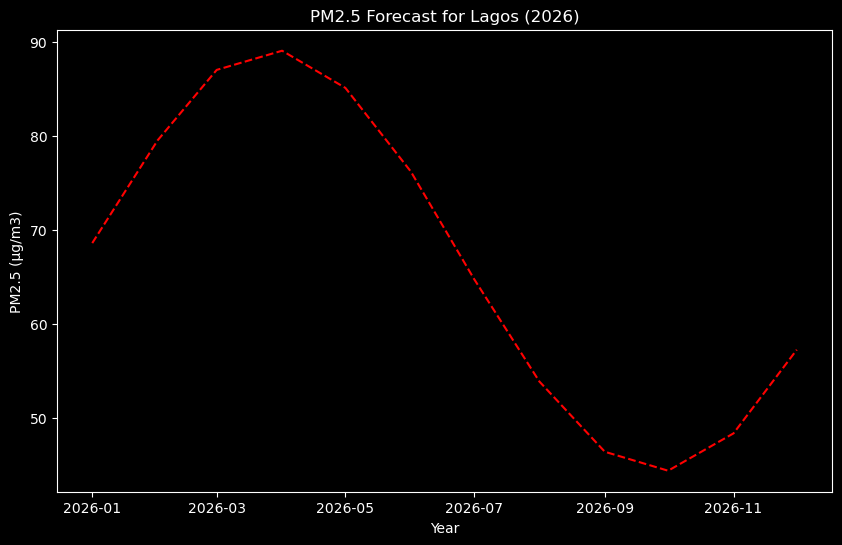

In [37]:
# Plot historical PM2.5 forecast data
plt.style.use("dark_background")
plt.figure(figsize=(10,6))

# Forecast data
plt.plot(forecast.index, forecast, label="Forecast (2026)", color="red", linestyle="--")

# Labels and title
plt.title("PM2.5 Forecast for Lagos (2026)")
plt.xlabel("Year")
plt.ylabel("PM2.5 (µg/m3)")

plt.savefig("Lagos_forecast.png")
plt.show()

The forecast visualization shows that PM2.5 levels in Lagos are expected to follow a seasonal pattern in 2026. Pollution levels are predicted to rise during the early months of the year, peak around April, decline during the mid-year rainy season, and increase again toward the end of the year.

In [18]:
# Convert the forecast to a table
lag_forecast = forecast.reset_index()
lag_forecast.columns = ['Date', 'Forecast_PM25']

In [19]:
lag_forecast

,Date,Forecast_PM25
0,2026-01-01,68.568141
1,2026-02-01,79.505314
2,2026-03-01,86.998977
3,2026-04-01,89.039992
4,2026-05-01,85.082434
5,2026-06-01,76.189609
6,2026-07-01,64.748373
7,2026-08-01,53.828489
8,2026-09-01,46.358994
9,2026-10-01,44.342540


In [20]:
# Save the forecast table
lag_forecast.to_csv("Lag_forecast_table.csv", index=False)

## Key Insights and  Impact

This project provides useful insights into air pollution trends both globally and in Lagos state. By analyzing past data and making future predictions, it helps identify the most polluted areas, understand how pollution changes over time, and anticipate future air quality levels.

The Lagos-focused analysis offers a closer look at how pollution behaves within the city, helping to highlight periods when air quality is worse. These insights can support better planning and timely actions to reduce the impact of high pollution levels.


## Conclusion
Through exploratory data analysis, clear differences in pollution levels across cities were identified, highlighting areas with consistently high air quality concerns. The global comparison revealed that pollution is unevenly distributed, with certain cities experiencing significantly higher concentrations than others.

Trend analysis showed that PM2.5 levels exhibit noticeable temporal patterns, including fluctuations over time and potential seasonal effects. In Lagos specifically, the data indicated periods of elevated pollution levels during certain months of the year, suggesting the influence of environmental and human factors such as weather conditions and urban activities.

To extend the analysis beyond historical trends, a time-series forecasting approach was implemented using an ARIMA model. The model captured the underlying temporal structure of the data and produced forecasts for the next 12 months. Results suggest that pollution levels may rise during the early part of the year, peak around the second quarter, and decline toward the later months before increasing again, indicating a cyclical pattern.

Overall, this analysis demonstrates the value of combining data exploration, visualization, and predictive modeling to better understand air quality dynamics. The insights generated can support informed decision-making, enabling stakeholders to anticipate high-risk periods and implement proactive measures to mitigate the impact of air pollution.

Future work could involve incorporating additional variables such as weather conditions, traffic data, and industrial activity to improve predictive accuracy and provide deeper insights into the drivers of air pollution.
